In [2]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\data\interim\train_1m_rows.parquet")
#print(df.head())

In [3]:
print(df.head())

                                         customer_ID        S_2       P_2  \
0  00000fd6641609c6ece5454664794f0340ad84dddce9a2... 2017-03-01  0.929122   
1  00000fd6641609c6ece5454664794f0340ad84dddce9a2... 2017-04-16  0.918431   
2  00000fd6641609c6ece5454664794f0340ad84dddce9a2... 2017-05-07  0.922563   
3  00000fd6641609c6ece5454664794f0340ad84dddce9a2... 2017-06-25  0.919253   
4  00000fd6641609c6ece5454664794f0340ad84dddce9a2... 2017-07-30  0.901860   

       D_39       B_1       B_2       R_1       S_3      D_41       B_3  ...  \
0  0.382790  0.025782  1.002647  0.005515  0.089799  0.001479  0.005830  ...   
1  0.002224  0.006806  1.008186  0.003287  0.095966  0.007831  0.000861  ...   
2  0.567403  0.033713  1.007497  0.005594  0.094655  0.003162  0.010466  ...   
3  0.213193  0.031170  1.008534  0.008996  0.099089  0.009513  0.005360  ...   
4  0.325467  0.109644  1.005098  0.008041  0.108525  0.000732  0.005484  ...   

   D_136  D_137  D_138     D_139     D_140     D_141  D_

In [4]:
print(df.shape)

(1000012, 190)


In [5]:
labels = pd.read_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\data\interim\train_1m_labels.parquet")
print(labels.head())

                                         customer_ID  target
0  00000fd6641609c6ece5454664794f0340ad84dddce9a2...       0
1  00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...       0
2  0000f99513770170a1aba690daeeb8a96da4a39f11fc27...       1
3  000201146e53cacdde1c7e9d29f4d3c46fd4d9231a3744...       0
4  00031e8be98bc3411f6037cbd4d3eeaf24b3ae221682b7...       0


In [6]:
print(labels.shape)

(83121, 2)


In [7]:
pd.set_option('display.max_columns', None)
df.head().T

,0,1,2,3,4
customer_ID,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,00000fd6641609c6ece5454664794f0340ad84dddce9a2...
S_2,2017-03-01 00:00:00,2017-04-16 00:00:00,2017-05-07 00:00:00,2017-06-25 00:00:00,2017-07-30 00:00:00
P_2,0.929122,0.918431,0.922563,0.919253,0.90186
D_39,0.38279,0.002224,0.567403,0.213193,0.325467
B_1,0.025782,0.006806,0.033713,0.03117,0.109644
...,...,...,...,...,...
D_141,0.0082,0.001375,0.009851,0.004284,0.006918
D_142,NaN,NaN,NaN,NaN,NaN
D_143,0.001061,0.009999,0.000996,0.002642,0.009869
D_144,0.000027,0.002669,0.003254,0.004325,0.002979


In [8]:
!pip install itables
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)
df


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head()

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [10]:
#df = pd.read_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\data\interim\train_1m_rows.parquet")
# categorical variables according to Kaggle:

cat_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']

present = [c for c in cat_cols if c in df.columns]
missing = [c for c in cat_cols if c not in df.columns]
print("Present categorical cols:", present)
print("Missing (not in your file):", missing)
print()

print("Dtypes of present categorical cols:")
print(df[present].dtypes)
print()

print("Unique value counts:")
print(df[present].nunique())
print()

print("Sample of actual values per categorical column:")
for c in present:
    print(f"\n{c}:")
    print(df[c].value_counts(dropna=False).head(10))

Present categorical cols: ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
Missing (not in your file): []

Dtypes of present categorical cols:
B_30     string
B_38     string
D_114    string
D_116    string
D_117    string
D_120    string
D_126    string
D_63     string
D_64     string
D_66     string
D_68     string
dtype: object

Unique value counts:
B_30     3
B_38     7
D_114    2
D_116    2
D_117    7
D_120    2
D_126    3
D_63     6
D_64     4
D_66     2
D_68     7
dtype: int64

Sample of actual values per categorical column:

B_30:
B_30
0.0     848157
1.0     141392
2.0      10090
<NA>       373
Name: count, dtype: int64[pyarrow]

B_38:
B_38
2.0     347438
3.0     227983
1.0     209630
5.0      81164
4.0      55252
7.0      47552
6.0      30620
<NA>       373
Name: count, dtype: int64[pyarrow]

D_114:
D_114
1.0     594448
0.0     372929
<NA>     32635
Name: count, dtype: int64[pyarrow]

D_116:
D_116
0.0     966131
<NA>     32635
1.0  

In [11]:
print(df['D_63'].unique())

<ArrowStringArray>
['CO', 'CR', 'CL', 'XL', 'XM', 'XZ']
Length: 6, dtype: string


In [12]:
#Before Encoding, standardize into clean, consistent category labels:

#for c in present:
#    df[c] = df[c].astype(str).str.replace(r'\.0$', '', regex=True)
#    df[c] = df[c].replace('nan', pd.NA)  # guard against the string "nan" creeping in

In [13]:
### Exploratory Data Analysis

In [14]:
### 1 - Structure

In [15]:
#import pandas as pd
import numpy as np

#df = pd.read_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\data\interim\train_1m_rows.parquet")
#labels = pd.read_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\data\interim\train_1m_labels.parquet")

print("Features shape:", df.shape)
print("Labels shape:", labels.shape)
print()
print(df.dtypes.value_counts())  # how many cols per dtype
print()
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1e6)

# df.memory_usage(deep=True).sum() / 1e6 tells you how much RAM your DataFrame is actually using, 
#in megabytes.

# Breaking it down:

# df.memory_usage(deep=True) returns a Series showing how many bytes each column takes up in memory. 
# Without deep=True, pandas only estimates memory for object/string columns (often wildly 
#underestimating them, since it just counts pointer size, not actual string content). 
# With deep=True, it inspects the actual objects and gives you a true count — important here since 
#customer_ID is a string column.

# .sum() adds up the per-column byte counts into a single total.
# / 1e6 converts bytes → megabytes (1e6 = 1,000,000).

# result means: your DataFrame is taking up ~ ___ GB in RAM.

# With 190 columns × 1M rows, this number tells you whether you're close to exhausting your 
#machine's RAM — especially relevant once you start creating engineered features (aggregations, 
#rolling stats, etc.) that temporarily double or triple memory usage during computation. 
# If this number is uncomfortably high relative to your available RAM, it's a sign to consider 
#downcasting dtypes (e.g. float64 → float32, or object → category for the categorical columns) 
#before doing further analysis.

Features shape: (1000012, 190)
Labels shape: (83121, 2)

float32           175
string             13
str                 1
datetime64[us]      1
Name: count, dtype: int64

Memory usage (MB): 913.430404


In [16]:
# Check customer overlap between the two files
feat_ids = set(df['customer_ID'].unique())
label_ids = set(labels['customer_ID'].unique())

print("Unique customers in features:", len(feat_ids))
print("Unique customers in labels:", len(label_ids))
print("In features but not labels:", len(feat_ids - label_ids))
print("In labels but not features:", len(label_ids - feat_ids))

Unique customers in features: 83121
Unique customers in labels: 83121
In features but not labels: 0
In labels but not features: 0


count    83121.000000
mean        12.030798
std          2.640916
min          1.000000
25%         13.000000
50%         13.000000
75%         13.000000
max         13.000000
dtype: float64


<Axes: >

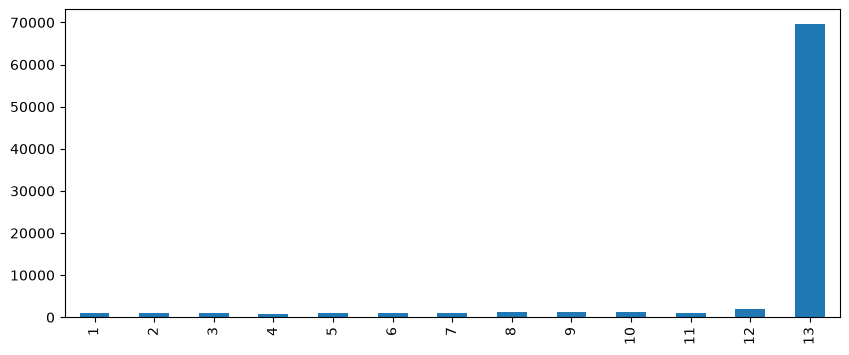

In [17]:
# Statements per customer — confirms the panel structure
stmt_counts = df.groupby('customer_ID').size()
print(stmt_counts.describe())
stmt_counts.value_counts().sort_index().plot(kind='bar', figsize=(10,4))

In [18]:
### 2 - Trends

In [19]:
# Class balance — the most important number in the whole project
print(labels['target'].value_counts(normalize=True))

target
0    0.730393
1    0.269607
Name: proportion, dtype: float64


In [20]:
# Summary stats per feature group
groups = {
    'D': [c for c in df.columns if c.startswith('D_')],
    'S': [c for c in df.columns if c.startswith('S_')],
    'P': [c for c in df.columns if c.startswith('P_')],
    'B': [c for c in df.columns if c.startswith('B_')],
    'R': [c for c in df.columns if c.startswith('R_')],
}
for name, cols in groups.items():
    print(f"{name}_ : {len(cols)} columns")

df[groups['B']].describe().T.head(10)  # example: balance features

D_ : 96 columns
S_ : 22 columns
P_ : 3 columns
B_ : 40 columns
R_ : 28 columns


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [21]:
# Correlation of last-statement features with target (cheap signal check)
last_stmt = df.sort_values('S_2').groupby('customer_ID').last().reset_index()
merged = last_stmt.merge(labels, on='customer_ID')

numeric_cols = merged.select_dtypes(include=np.number).columns.drop('target', errors='ignore')
corrs = merged[numeric_cols].corrwith(merged['target']).sort_values(key=abs, ascending=False)
print(corrs.head(20))

P_2    -0.670334
D_48    0.615029
B_2    -0.560993
D_61    0.553188
B_18   -0.549788
B_9     0.546965
D_55    0.528278
B_33   -0.524583
D_44    0.524262
B_3     0.506558
B_7     0.505198
D_58    0.499830
D_75    0.499330
B_23    0.497833
R_1     0.471120
B_16    0.470170
B_20    0.460672
B_4     0.460233
D_74    0.459461
B_19    0.453807
dtype: float64


In [22]:
### Fresh Start ###

In [23]:
# First, a column-level overview across everything, not just the 11 known categoricals — 
#sentinels could be lurking elsewhere too.
overview = []
for c in df.columns:
    if c in ['customer_ID', 'S_2']:
        continue
    s = df[c]
    overview.append({
        'col': c,
        'dtype': s.dtype,
        'nunique': s.nunique(dropna=True),
        'pct_missing': s.isna().mean() * 100,
    })

overview_df = pd.DataFrame(overview).sort_values('nunique')
print(overview_df.head(30))  # low-cardinality columns are your prime sentinel suspects

       col    dtype  nunique  pct_missing
106   D_87   string        1    99.925901
110   B_31   string        2     0.000000
58    D_66   string        2    88.589037
155  D_116   string        2     3.263461
153  D_114   string        2     3.263461
159  D_120   string        2     3.263461
165  D_126   string        3     2.156974
103   B_30   string        3     0.037300
52    D_64   string        4     4.007052
51    D_63   string        6     0.000000
60    D_68   string        7     3.985552
156  D_117   string        7     3.263461
143   B_38   string        7     0.037300
109   D_88  float32     1107    99.889301
144  D_108  float32     5307    99.469306
147  D_111  float32     5725    99.415507
146  D_110  float32     5815    99.415507
148   B_39  float32     6295    99.370408
72    D_73  float32    10455    98.954313
170   B_42  float32    12287    98.771115
178  D_136  float32    35374    96.392043
180  D_138  float32    35772    96.392043
176  D_134  float32    36009    96

In [24]:
# Now specifically hunt for sentinel values among the numeric columns — anything sitting 
#suspiciously below the rest of the distribution (-1, -999, etc.):

numeric_cols = df.select_dtypes(include=np.number).columns
sentinel_check = []
for c in numeric_cols:
    s = df[c]
    sentinel_check.append({
        'col': c,
        'min': s.min(),
        'max': s.max(),
        'pct_neg1': (s == -1).mean() * 100,
        'pct_negative': (s < 0).mean() * 100,
    })

sentinel_df = pd.DataFrame(sentinel_check)
print(sentinel_df[sentinel_df['pct_negative'] > 0].sort_values('pct_negative', ascending=False))

# these are columns where pct_negative is greater than 0

       col        min          max  pct_neg1  pct_negative
122   S_23 -31.904741   167.636047       0.0      1.016188
90    R_12  -0.091707     1.010000       0.0      1.011688
124   S_25  -2.453437     3.346180       0.0      1.002588
0      P_2  -0.442723     1.010000       0.0      0.975588
57    S_12  -0.387936   101.924835       0.0      0.974188
27     P_3  -1.266380     2.353487       0.0      0.928389
148  D_121  -0.032074     1.790079       0.0      0.842590
16    D_47  -0.026620     1.382467       0.0      0.789391
15    D_46 -17.289343    16.319901       0.0      0.766191
5      S_3  -0.545006     3.582628       0.0      0.715191
35     S_7  -0.405593     2.582711       0.0      0.689692
47    D_61  -0.009258     8.625372       0.0      0.683192
49    S_11  -0.199957     2.849923       0.0      0.674592
151  D_124  -0.045454     2.100848       0.0      0.601593
17    D_48  -0.009603     8.971425       0.0      0.475294
66    S_15  -0.300000     5.307165       0.0      0.4720

In [25]:
cat_cols = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117', 'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
present = [c for c in cat_cols if c in df.columns]

for c in present:
    print(f"\n{c}: {sorted(df[c].dropna().unique())}")


B_30: ['0.0', '1.0', '2.0']

B_38: ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0']

D_114: ['0.0', '1.0']

D_116: ['0.0', '1.0']

D_117: ['-1.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0']

D_120: ['0.0', '1.0']

D_126: ['-1.0', '0.0', '1.0']

D_63: ['CL', 'CO', 'CR', 'XL', 'XM', 'XZ']

D_64: ['-1', 'O', 'R', 'U']

D_66: ['0.0', '1.0']

D_68: ['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0']


In [26]:
# Clean - normalize formatting, fix sentinel/missing confusion

for c in present:
    df[c] = df[c].astype(str).str.replace(r'\.0$', '', regex=True)
    df[c] = df[c].replace('nan', pd.NA)

# spot-check it worked
for c in present:
    print(c, sorted(df[c].dropna().unique()))

B_30 ['0', '1', '2']
B_38 ['1', '2', '3', '4', '5', '6', '7']
D_114 ['0', '1']
D_116 ['0', '1']
D_117 ['-1', '1', '2', '3', '4', '5', '6']
D_120 ['0', '1']
D_126 ['-1', '0', '1']
D_63 ['CL', 'CO', 'CR', 'XL', 'XM', 'XZ']
D_64 ['-1', 'O', 'R', 'U']
D_66 ['0', '1']
D_68 ['0', '1', '2', '3', '4', '5', '6']


In [27]:
# Based on D_117/D_126 investigation: -1 is a legitimate category, not missing — leave as is.
# If you find a column where -1 truly means "no data," convert it explicitly, e.g.:
# df['SOME_COL'] = df['SOME_COL'].replace('-1', pd.NA)

In [28]:
# Structure

print(df.dtypes.value_counts())
print("Memory usage (MB):", df.memory_usage(deep=True).sum() / 1e6)

stmt_counts = df.groupby('customer_ID').size()
print(stmt_counts.describe())

float32           175
str                12
string              2
datetime64[us]      1
Name: count, dtype: int64
Memory usage (MB): 897.712426
count    83121.000000
mean        12.030798
std          2.640916
min          1.000000
25%         13.000000
50%         13.000000
75%         13.000000
max         13.000000
dtype: float64


In [29]:
# Trends (now safe to compute, since sentinels are identified)

print(labels['target'].value_counts(normalize=True))

target
0    0.730393
1    0.269607
Name: proportion, dtype: float64


In [30]:
# Merging Process

last_stmt = df.sort_values('S_2').groupby('customer_ID').last().reset_index()
merged = last_stmt.merge(labels, on='customer_ID')

# exclude the known categorical/sentinel-bearing columns from raw correlation —
# they need encoding first, not naive Pearson correlation
corr_cols = [c for c in numeric_cols if c not in present]
corrs = merged[corr_cols].corrwith(merged['target']).sort_values(key=abs, ascending=False)
print(corrs.head(20)) # shows just the top 20 most predictive-looking features by this simple measure

P_2    -0.670334
D_48    0.615029
B_2    -0.560993
D_61    0.553188
B_18   -0.549788
B_9     0.546965
D_55    0.528278
B_33   -0.524583
D_44    0.524262
B_3     0.506558
B_7     0.505198
D_58    0.499830
D_75    0.499330
B_23    0.497833
R_1     0.471120
B_16    0.470170
B_20    0.460672
B_4     0.460233
D_74    0.459461
B_19    0.453807
dtype: float64


In [31]:
balance_cols = ['B_2', 'B_18', 'B_9', 'B_33', 'B_3', 'B_7', 'B_23', 'B_16', 'B_20', 'B_4', 'B_19']
print(merged[balance_cols].corr().round(2))

       B_2  B_18   B_9  B_33   B_3   B_7  B_23  B_16  B_20   B_4  B_19
B_2   1.00  0.86 -0.64  0.92 -0.72 -0.62 -0.61 -0.79 -0.79 -0.53 -0.64
B_18  0.86  1.00 -0.60  0.86 -0.67 -0.68 -0.68 -0.79 -0.76 -0.66 -0.58
B_9  -0.64 -0.60  1.00 -0.62  0.57  0.52  0.51  0.59  0.58  0.45  0.54
B_33  0.92  0.86 -0.62  1.00 -0.65 -0.55 -0.54 -0.79 -0.77 -0.50 -0.56
B_3  -0.72 -0.67  0.57 -0.65  1.00  0.65  0.66  0.74  0.77  0.57  0.80
B_7  -0.62 -0.68  0.52 -0.55  0.65  1.00  1.00  0.59  0.61  0.69  0.65
B_23 -0.61 -0.68  0.51 -0.54  0.66  1.00  1.00  0.59  0.62  0.73  0.64
B_16 -0.79 -0.79  0.59 -0.79  0.74  0.59  0.59  1.00  0.90  0.54  0.65
B_20 -0.79 -0.76  0.58 -0.77  0.77  0.61  0.62  0.90  1.00  0.56  0.67
B_4  -0.53 -0.66  0.45 -0.50  0.57  0.69  0.73  0.54  0.56  1.00  0.49
B_19 -0.64 -0.58  0.54 -0.56  0.80  0.65  0.64  0.65  0.67  0.49  1.00


In [32]:
print((merged['B_7'] - merged['B_23']).describe())  # check if it's an exact duplicate or just a linear scaling
#df = df.drop(columns=['B_23'])  # keep B_7, drop the redundant twin

count    83121.000000
mean         0.014345
std          0.024376
min         -0.268789
25%          0.005164
50%          0.012147
75%          0.022062
max          0.196873
dtype: float64


In [33]:
# Get the precise correlation, not the rounded display
print(merged['B_7'].corr(merged['B_23']))

# See if the difference correlates with target — i.e. does the gap between them carry signal?
diff = merged['B_7'] - merged['B_23']
print(diff.corr(merged['target']))

# don't drop because the second number is not small enough

0.9951082540058578
0.08474897096166752


In [34]:
# Issues

missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print(missing_pct.head(20))

dupes = df.duplicated(subset=['customer_ID', 'S_2']).sum()
print("Duplicate (customer_ID, S_2) pairs:", dupes)

nunique_all = df.nunique()
print("Constant columns:", list(nunique_all[nunique_all <= 1].index))

D_87     99.925901
D_88     99.889301
D_108    99.469306
D_111    99.415507
D_110    99.415507
B_39     99.370408
D_73     98.954313
B_42     98.771115
D_134    96.392043
D_138    96.392043
D_135    96.392043
D_136    96.392043
D_137    96.392043
R_9      94.181570
B_29     93.180582
D_106    90.102419
D_132    90.079819
D_49     90.027120
D_76     88.821134
R_26     88.799834
dtype: float64
Duplicate (customer_ID, S_2) pairs: 0
Constant columns: ['D_87']


In [35]:
# Outlier scan — now excludes the categorical columns, so -1 won't fake an outlier
cont_cols = [c for c in numeric_cols if c not in present]
z = (df[cont_cols] - df[cont_cols].mean()) / df[cont_cols].std()
outlier_frac = (z.abs() > 5).mean().sort_values(ascending=False)
print(outlier_frac.head(15))

D_86     0.031999
D_96     0.030786
R_4      0.027159
S_18     0.026054
R_12     0.022716
B_32     0.022407
D_140    0.021991
D_54     0.021023
R_19     0.018364
R_21     0.016925
D_94     0.016493
R_15     0.015411
R_24     0.014353
D_91     0.013408
S_20     0.012593
dtype: float64


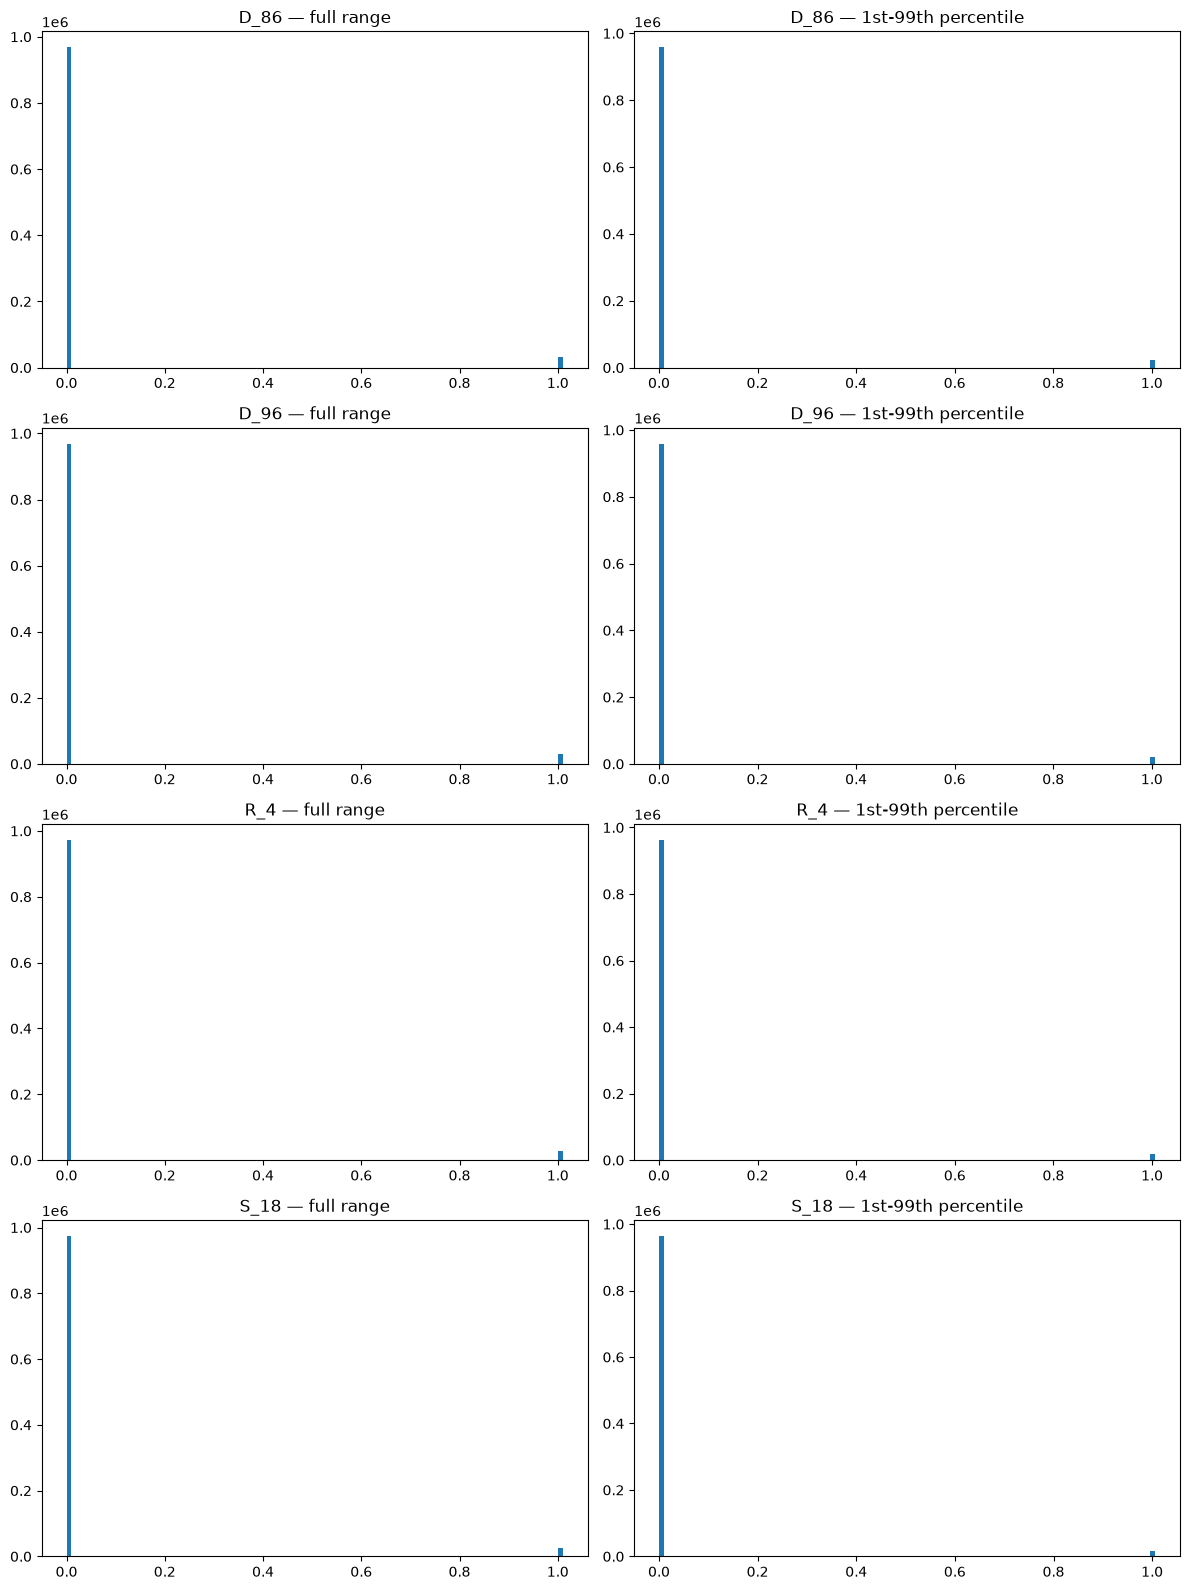

In [36]:
import matplotlib.pyplot as plt

check_cols = ['D_86', 'D_96', 'R_4', 'S_18']

fig, axes = plt.subplots(len(check_cols), 2, figsize=(12, 4*len(check_cols)))

for i, c in enumerate(check_cols):
    data = df[c].dropna()
    
    # Full distribution
    axes[i, 0].hist(data, bins=100)
    axes[i, 0].set_title(f'{c} — full range')
    
    # Zoomed in on the bulk (1st-99th percentile), ignoring extreme tails
    p1, p99 = data.quantile([0.01, 0.99])
    axes[i, 1].hist(data[(data >= p1) & (data <= p99)], bins=100)
    axes[i, 1].set_title(f'{c} — 1st-99th percentile')

plt.tight_layout()
plt.show()

In [37]:
from scipy.stats import skew, kurtosis

for c in check_cols:
    data = df[c].dropna()
    print(f"\n{c}:")
    print(f"  skew: {skew(data):.2f}  (0 = symmetric, >1 = strongly right-skewed)")
    print(f"  kurtosis: {kurtosis(data):.2f}  (0 = normal-like tails, high = heavy tails/spikes)")
    print(f"  percentiles: 1%={data.quantile(0.01):.3f}  50%={data.quantile(0.5):.3f}  99%={data.quantile(0.99):.3f}  99.9%={data.quantile(0.999):.3f}")


D_86:
  skew: 5.32  (0 = symmetric, >1 = strongly right-skewed)
  kurtosis: 26.27  (0 = normal-like tails, high = heavy tails/spikes)
  percentiles: 1%=0.000  50%=0.005  99%=1.007  99.9%=1.010

D_96:
  skew: 5.43  (0 = symmetric, >1 = strongly right-skewed)
  kurtosis: 27.50  (0 = normal-like tails, high = heavy tails/spikes)
  percentiles: 1%=0.000  50%=0.005  99%=1.007  99.9%=1.010

R_4:
  skew: 5.82  (0 = symmetric, >1 = strongly right-skewed)
  kurtosis: 31.83  (0 = normal-like tails, high = heavy tails/spikes)
  percentiles: 1%=0.000  50%=0.005  99%=1.006  99.9%=1.010

S_18:
  skew: 5.95  (0 = symmetric, >1 = strongly right-skewed)
  kurtosis: 33.39  (0 = normal-like tails, high = heavy tails/spikes)
  percentiles: 1%=0.000  50%=0.005  99%=1.006  99.9%=1.010


In [38]:
# Check specifically whether extreme values are spread out or clumped at one repeated number
# (a repeated extreme value = likely a sentinel/error code; spread out = likely a genuine long tail)
for c in check_cols:
    s = df[c]
    mean, std = s.mean(), s.std()
    extreme = s[(s - mean).abs() / std > 5]
    print(f"\n{c}: {len(extreme)} extreme values")
    if len(extreme) > 0:
        print(extreme.value_counts().head(10))


D_86: 31999 extreme values
D_86
1.009269    6
1.005486    5
1.009992    5
1.004101    5
1.008292    5
1.009943    5
1.001480    5
1.007201    4
1.007554    4
1.008386    4
Name: count, dtype: int64

D_96: 30786 extreme values
D_96
1.006045    5
1.002872    5
1.000752    4
1.007917    4
1.000514    4
1.005967    4
1.003733    4
1.005126    4
1.003103    4
1.009047    4
Name: count, dtype: int64

R_4: 27159 extreme values
R_4
1.000719    5
1.008805    5
1.006519    4
1.006307    4
1.007244    4
1.001684    4
1.008266    4
1.004584    4
1.004837    4
1.006215    4
Name: count, dtype: int64

S_18: 26054 extreme values
S_18
1.000550    5
1.009393    5
1.008016    4
1.000666    4
1.003952    4
1.003510    4
1.007451    4
1.005705    4
1.004773    4
1.008008    4
Name: count, dtype: int64


In [39]:
# carry on after exam

In [42]:
import pandas as pd
import numpy as np

# Sort chronologically first — critical for "last" and trend features to be meaningful
df = df.sort_values('S_2')

# --- Numeric columns ---
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Aggregations: last (most recent snapshot), mean (average behavior), 
# std (volatility/variability), min, max, and trend (last minus first = direction of change)
aggs = {c: ['last', 'mean', 'std', 'min', 'max'] for c in num_cols}
num_features = df.groupby('customer_ID')[num_cols].agg(aggs)
num_features.columns = ['_'.join(col) for col in num_features.columns]  # e.g. P_2_last, P_2_mean

# Trend: last - first (captures direction of change, e.g. balance increasing vs decreasing)
first_vals = df.groupby('customer_ID')[num_cols].first()
last_vals  = df.groupby('customer_ID')[num_cols].last()
trend = (last_vals - first_vals).add_suffix('_trend')

# Categorical columns — separate last and mode, then concat
cat_last = df.groupby('customer_ID')[present].last().add_suffix('_last')
cat_mode = df.groupby('customer_ID')[present].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA
).add_suffix('_mode')
cat_features = pd.concat([cat_last, cat_mode], axis=1)

# Statement count
stmt_count = df.groupby('customer_ID').size().rename('stmt_count')

# Combine
features = pd.concat([num_features, trend, cat_features, stmt_count], axis=1).reset_index()
features = features.merge(labels, on='customer_ID')
print("Final feature matrix shape:", features.shape)

Final feature matrix shape: (83121, 1075)


C:\Users\timio\AppData\Local\Temp\ipykernel_1256\2445787039.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features = pd.concat([num_features, trend, cat_features, stmt_count], axis=1).reset_index()


In [43]:
print(df[['D_86', 'D_96', 'R_4', 'S_18']].corr())

          D_86      D_96       R_4      S_18
D_86  1.000000  0.135584 -0.016815  0.072209
D_96  0.135584  1.000000 -0.018924  0.167312
R_4  -0.016815 -0.018924  1.000000 -0.009835
S_18  0.072209  0.167312 -0.009835  1.000000


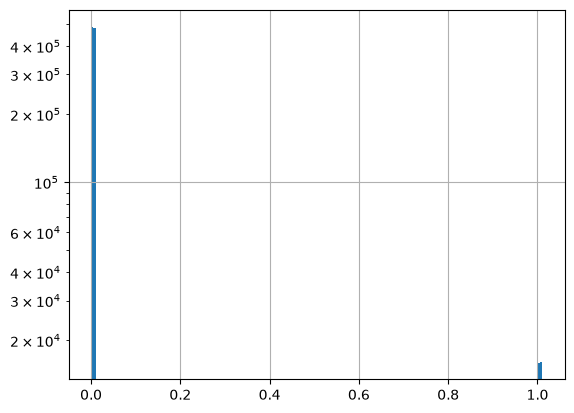

In [44]:
import matplotlib.pyplot as plt
df['D_86'].hist(bins=200)
plt.yscale('log')  # so the small upper cluster is visible next to the dominant near-zero spike

In [45]:
features = pd.concat([num_features, trend, cat_features, stmt_count], axis=1).reset_index().copy()

C:\Users\timio\AppData\Local\Temp\ipykernel_1256\4243931705.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features = pd.concat([num_features, trend, cat_features, stmt_count], axis=1).reset_index().copy()


In [46]:
# Save it (run this once, immediately after features is created):
#features.to_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\timi_notebooks\features_engineered.parquet", index=False)
#print("Saved.")


Saved.


In [47]:
#Also worth saving df (the raw loaded + cleaned panel data) in case you need to go back and re-engineer features differently:
#df.to_parquet(r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\timi_notebooks\train_cleaned.parquet", index=False)

In [48]:
# D_87: 99.9% missing AND constant where present — zero information
features = features.drop(columns=[c for c in features.columns if c.startswith('D_87')])

# Any column that ended up entirely constant post-aggregation
nunique = features.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
print("Dropping constant columns:", constant_cols)
features = features.drop(columns=constant_cols)

Dropping constant columns: []


In [49]:
#Columns w6']


In [51]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100

# Show all columns with any meaningful missingness
print("Columns with >10% missing:")
print(missing_pct[missing_pct > 10])

print(f"\nTotal columns with >10% missing: {(missing_pct > 10).sum()}")
print(f"Total columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Total columns with any missing:  {(missing_pct > 0).sum()}")
print(f"Total columns with zero missing: {(missing_pct == 0).sum()}")

Columns with >10% missing:
D_87     99.925901
D_88     99.889301
D_108    99.469306
D_111    99.415507
D_110    99.415507
B_39     99.370408
D_73     98.954313
B_42     98.771115
D_134    96.392043
D_138    96.392043
D_135    96.392043
D_136    96.392043
D_137    96.392043
R_9      94.181570
B_29     93.180582
D_106    90.102419
D_132    90.079819
D_49     90.027120
D_76     88.821134
R_26     88.799834
D_66     88.589037
D_42     85.418275
D_142    82.623409
D_53     73.635916
D_82     73.598517
D_50     57.225413
B_17     56.269125
D_105    54.418247
D_56     54.408047
S_9      53.332160
D_77     45.856050
D_43     29.899141
S_27     25.291796
D_46     22.041036
S_3      18.364480
S_7      18.364480
D_62     13.659136
D_48     13.048343
D_61     10.817570
dtype: float64

Total columns with >10% missing: 39
Total columns with >50% missing: 30
Total columns with any missing:  120
Total columns with zero missing: 70


In [52]:
#updated missingness
high_missing = [
    'D_87', 'D_88', 'D_108', 'D_111', 'D_110', 'B_39',
    'D_73', 'B_42', 'D_134', 'D_138', 'D_135', 'D_136',
    'D_137', 'R_9', 'B_29', 'D_106', 'D_132', 'D_49',
    'D_76', 'R_26', 'D_66',
    'D_42', 'D_142', 'D_53', 'D_82', 'D_50',
    'B_17', 'D_105', 'D_56', 'S_9',
    # moderate missingness (>20%)
    'D_77', 'D_43', 'S_27', 'D_46'
]

for c in high_missing:
    last_col = f'{c}_last'
    if last_col in features.columns:
        features[f'{c}_was_missing'] = features[last_col].isna().astype(int)

# Confirm how many indicator columns were added
added = [f'{c}_was_missing' for c in high_missing if f'{c}_last' in features.columns]
print(f"Added {len(added)} missing indicator columns")
print(features.shape)

Added 33 missing indicator columns
(83121, 1107)


In [50]:
bimodal_candidates = []

for c in num_cols:
    s = df[c].dropna()
    if len(s) == 0:
        continue
    
    # The bimodal signature we found: median near 0, 99th percentile near 1,
    # and almost nothing in between (very few values in the 0.1-0.9 range)
    median = s.median()
    p99 = s.quantile(0.99)
    pct_middle = ((s > 0.1) & (s < 0.9)).mean()  # fraction of values in the "gap"
    
    if median < 0.05 and p99 > 0.9 and pct_middle < 0.05:
        bimodal_candidates.append({
            'col': c,
            'median': median,
            'p99': p99,
            'pct_in_gap': pct_middle * 100,  # % of values between 0.1 and 0.9
            'pct_near_zero': (s <= 0.1).mean() * 100,
            'pct_near_one': (s >= 0.9).mean() * 100,
        })

bimodal_df = pd.DataFrame(bimodal_candidates).sort_values('pct_in_gap')
print(f"Found {len(bimodal_df)} bimodal candidates:")
print(bimodal_df.to_string())

Found 50 bimodal candidates:
      col    median       p99  pct_in_gap  pct_near_zero  pct_near_one
0     R_2  0.005227  1.007690    0.000000      95.623853      4.376147
27   B_32  0.005121  1.005533    0.000000      97.759327      2.240673
28   S_20  0.005062  1.002074    0.000000      98.740715      1.259285
29   R_20  0.005078  1.006393    0.000000      98.449498      1.550502
30   R_21  0.005081  1.004066    0.000000      98.307520      1.692480
31   D_92  0.005442  1.009214    0.000000      91.909297      8.090703
32   D_93  0.005054  1.000019    0.000000      98.997212      1.002788
33   D_94  0.005084  1.003893    0.000000      98.350720      1.649280
34   R_24  0.005066  1.003070    0.000000      98.564717      1.435283
35   D_96  0.005158  1.006790    0.000000      96.921437      3.078563
36  D_103  0.009331  1.009781    0.000000      53.549538     46.450462
37  D_104  0.009338  1.005307    0.000000      53.549538     46.450462
38  D_108  0.005326  1.009893    0.000000      9

In [54]:
#Binary Flag Code for bimodal columns

# Group 1 & 2: clean bimodal (pct_in_gap == 0) — reliable binary flag
clean_bimodal = bimodal_df[bimodal_df['pct_in_gap'] == 0]['col'].tolist()

# Group 3: fuzzy bimodal (pct_in_gap > 0) — add flag but less critical
fuzzy_bimodal = bimodal_df[bimodal_df['pct_in_gap'] > 0]['col'].tolist()

all_bimodal = clean_bimodal + fuzzy_bimodal

for c in all_bimodal:
    last_col = f'{c}_last'
    if last_col in features.columns:
        features[f'{c}_is_high'] = (features[last_col] > 0.5).astype(int)

print(f"Added binary flags for {len([c for c in all_bimodal if f'{c}_last' in features.columns])} bimodal columns")
print(features.shape)

# Justification: A linear model won't naturally learn the threshold effect in a bimodal 
#column — the relationship between the raw value and target isn't linear, it's 
#step-function-shaped. The explicit binary flag makes that threshold directly available 
#to the model. Tree-based models will find this themselves anyway, so the flag is a 
#helpful nudge for linear models but doesn't hurt trees either.

Added binary flags for 50 bimodal columns
(83121, 1157)


In [53]:
print(df[['D_103', 'D_104']].corr())
print((df['D_103'] - df['D_104']).describe())

          D_103     D_104
D_103  1.000000  0.999747
D_104  0.999747  1.000000
count    981325.000000
mean          0.016663
std           0.020924
min          -0.153036
25%          -0.000538
50%           0.005382
75%           0.037225
max           0.065124
dtype: float64


In [55]:
#Categorical Encoder
# Explicitly target only the _last and _mode categorical aggregation columns
cat_agg_cols = [f'{cat}_{suffix}' 
                for cat in present 
                for suffix in ['last', 'mode']
                if f'{cat}_{suffix}' in features.columns]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for c in cat_agg_cols:
    features[c] = features[c].fillna('MISSING')
    features[c] = le.fit_transform(features[c].astype(str))

In [57]:
# Impute remaining missing values

from sklearn.impute import SimpleImputer
#import numpy as np

# Separate numeric and categorical post-encoding
num_feature_cols = features.select_dtypes(include=np.number).columns.drop(['target'], errors='ignore')

# Median imputation: robust to outliers (important given B_10, B_6 scale we found)
# Note: LightGBM can handle NaN natively — if using LGBM, you can skip this entirely
imputer = SimpleImputer(strategy='median')
features[num_feature_cols] = imputer.fit_transform(features[num_feature_cols])

In [58]:
from sklearn.preprocessing import StandardScaler

# Identify binary columns to exclude from scaling
binary_cols = (
    [f'{c}_was_missing' for c in high_missing if f'{c}_was_missing' in features.columns] +
    [f'{c}_is_high' for c in all_bimodal if f'{c}_is_high' in features.columns]
)

# Only scale genuine continuous columns
scale_cols = [c for c in features.select_dtypes(include=np.number).columns
              if c not in binary_cols
              and c != 'target']

scaler = StandardScaler()
features[scale_cols] = scaler.fit_transform(features[scale_cols])

In [59]:
import joblib
# Save the scaler — you'll need it later to scale new/test data the same way
# When you eventually make predictions on new data, that new data needs to go through the
#exact same scaling transformation — using the same mean and std values the scaler 
#learned from your training data. If you don't save it now, you'd have to refit it later,
#which risks slight inconsistencies.
joblib.dump(scaler, r"C:\Users\timio\Documents\StatLearningLocal\amex-default-prediction-project\timi_notebooks\scaler.pkl")

['C:\\Users\\timio\\Documents\\StatLearningLocal\\amex-default-prediction-project\\timi_notebooks\\scaler.pkl']

In [62]:
print('customer_ID' in features.columns)
print('target' in features.columns)
print(features.columns.tolist()[:10])  # first 10 column names

True
False
['customer_ID', 'P_2_last', 'P_2_mean', 'P_2_std', 'P_2_min', 'P_2_max', 'D_39_last', 'D_39_mean', 'D_39_std', 'D_39_min']


In [63]:
features = features.merge(labels[['customer_ID', 'target']], on='customer_ID', how='left')
print('target' in features.columns)  # should now be True
print(features.shape)

True
(83121, 1158)


In [64]:
# This block does two things: sets up the ingredients needed for model training, and 
#defines a reusable function that runs cross-validation for any model you hand it.

import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# --- Setup ---
X = features.drop(columns=['customer_ID', 'target'])
y = features['target']

# StratifiedKFold preserves class balance in each fold — critical for imbalanced data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
results = {}

def run_cv(model, model_name, X, y, skf):
    oof_preds = np.zeros(len(y))  # out-of-fold predictions
    fold_aucs = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        
        val_preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = val_preds
        
        fold_auc = roc_auc_score(y_val, val_preds)
        fold_aucs.append(fold_auc)
        print(f"  Fold {fold+1} AUC: {fold_auc:.4f}")
    
    overall_auc = roc_auc_score(y, oof_preds)
    print(f"  {model_name} Overall OOF AUC: {overall_auc:.4f} | Std: {np.std(fold_aucs):.4f}\n")
    
    return oof_preds, overall_auc

In [65]:
# --- Model 1: Logistic Regression (baseline) ---
print("=== Logistic Regression ===")
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_preds, lr_auc = run_cv(lr, 'Logistic Regression', X, y, skf)
results['Logistic Regression'] = lr_auc

=== Logistic Regression ===
  Fold 1 AUC: 0.9554
  Fold 2 AUC: 0.9561
  Fold 3 AUC: 0.9522
  Fold 4 AUC: 0.9522
  Fold 5 AUC: 0.9545
  Logistic Regression Overall OOF AUC: 0.9541 | Std: 0.0016



In [66]:
# --- Model 2: Random Forest ---
print("=== Random Forest ===")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_preds, rf_auc = run_cv(rf, 'Random Forest', X, y, skf)
results['Random Forest'] = rf_auc

=== Random Forest ===
  Fold 1 AUC: 0.9516
  Fold 2 AUC: 0.9503
  Fold 3 AUC: 0.9487
  Fold 4 AUC: 0.9475
  Fold 5 AUC: 0.9488
  Random Forest Overall OOF AUC: 0.9494 | Std: 0.0014

